<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/objective2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'Wav2Vec2PhonemeCTCTokenizer'. 
The class this function is called from is 'Wav2Vec2CTCTokenizer'.


Processing Objective 2: objective2.wav
Sequence: ʃ i s i z j uː

--- 4. Extraction of ALL Phoneme Segments ---


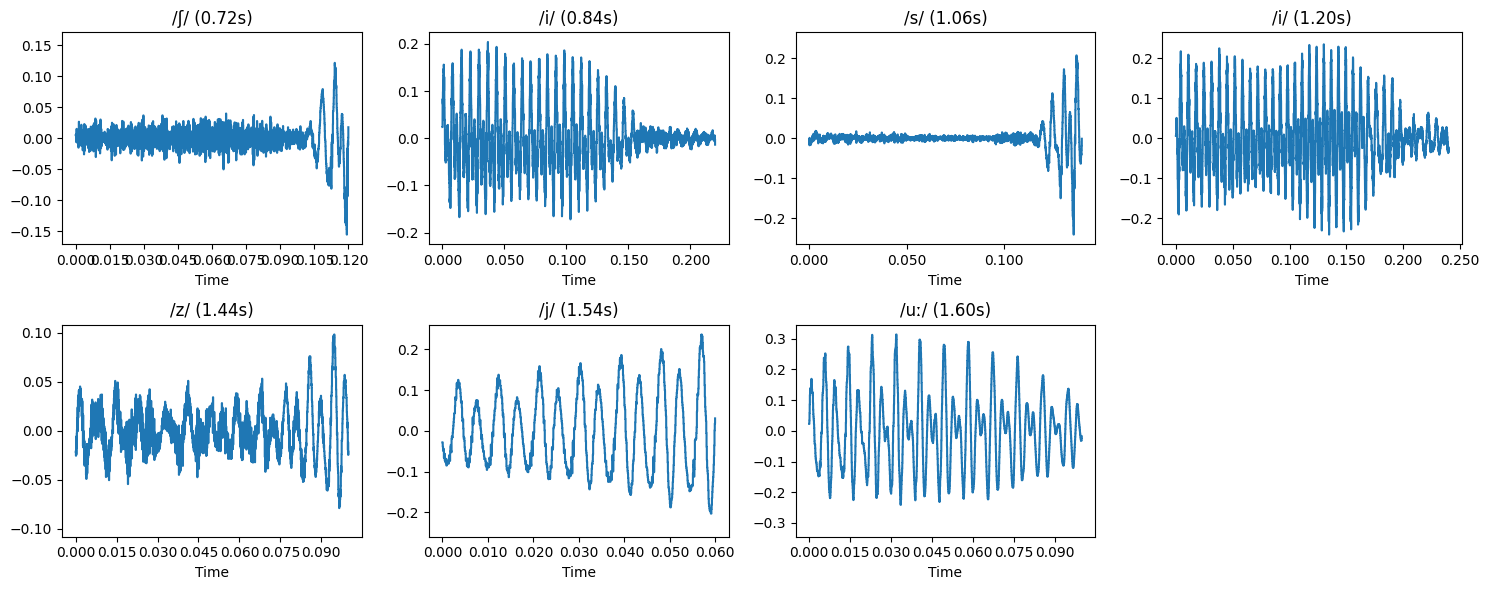


--- 5. Fricative vs Approximant Identification ---
Found Fricative: /ʃ/ at 0.72s
Found Fricative: /s/ at 1.06s
Found Fricative: /z/ at 1.44s
Found Approximant: /j/ at 1.54s

Comparing 3 Fricatives and 1 Approximants...


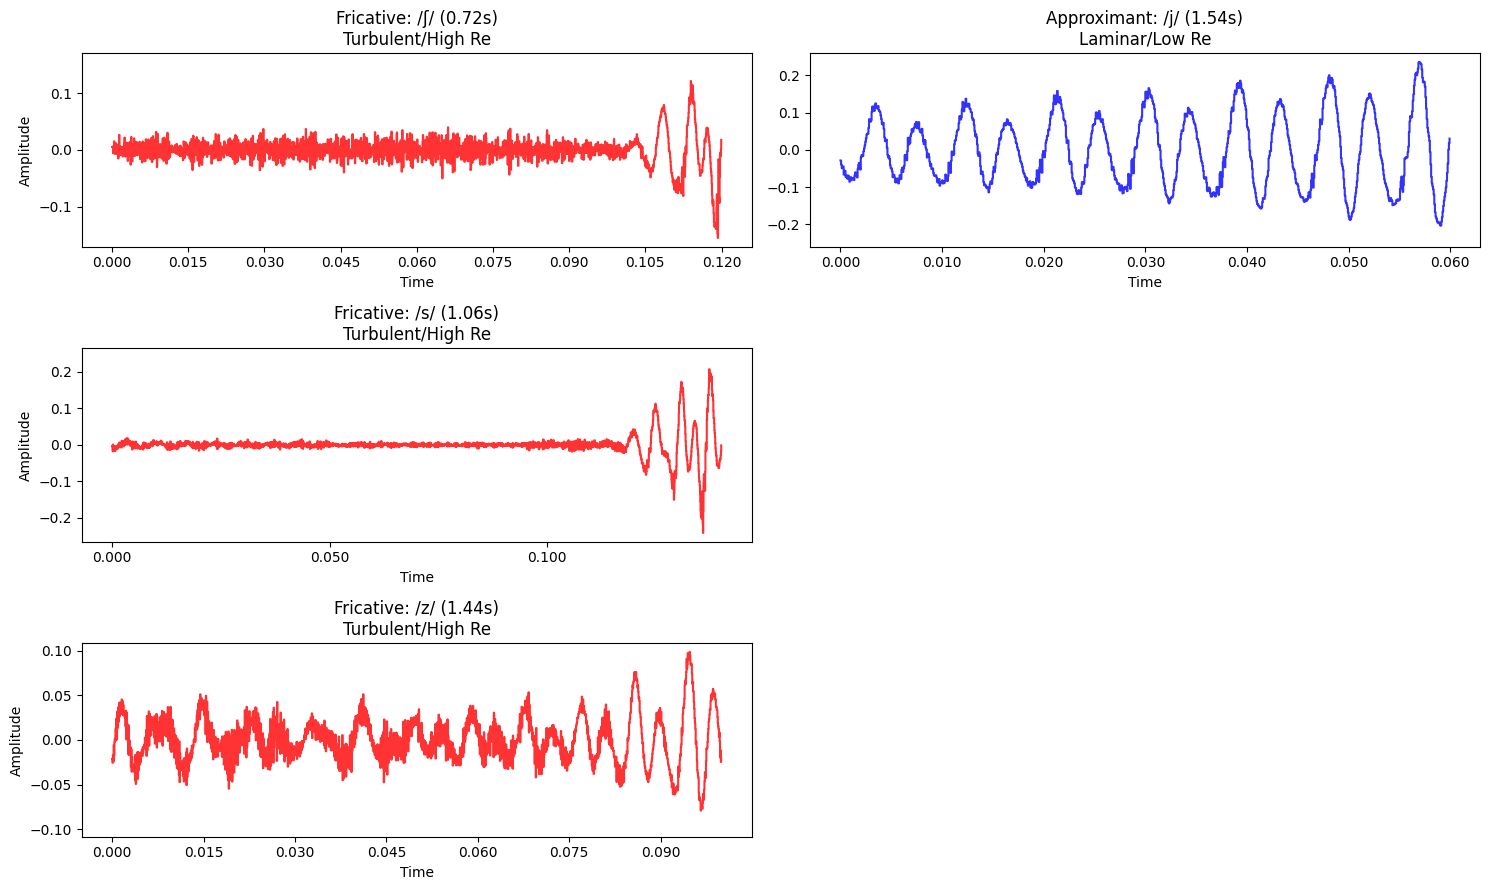


QUANTITATIVE ENERGY ANALYSIS
Average RMS Energy (Fricatives)  : 0.01797
Average RMS Energy (Approximants): 0.06586
Energy Ratio (Approximant/Fricative): 3.66x
>> Observation: Approximants have HIGHER energy.

CONCEPTUAL INFERENCE & ARTICULATORY ANALYSIS

1. FRICATIVES (/s/, /ʃ/, /z/)
   - Waveform: Irregular, random noise-like pattern (aperiodic).
   - Amplitude: Varies, but often dense/noisy.
   - Energy: Generally LOWER than vowels/approximants due to lack of distinct resonance.
   - Articulatory Physics: Produced by a NARROW CONSTRICTION in the vocal tract.
   - Fluid Dynamics: The narrow channel forces air to move fast, increasing the Reynolds Number.
   - Result: TURBULENT AIRFLOW (Chaos/High Reynolds Number). This creates the 'hissing' sound.

2. APPROXIMANTS (/j/, /w/, /r/)
   - Waveform: Smooth, periodic (repeating) structure, similar to vowels.
   - Amplitude: Continuous, higher energy, distinct peaks.
   - Energy: HIGHER due to laminar flow and vocal cord vibration (voicing)

In [ ]:
# ==========================================
# OBJECTIVE 2: FRICATIVE VS APPROXIMANT ANALYSIS
# ==========================================
!pip install torch torchaudio librosa transformers matplotlib phonemizer

# 1. SETUP (Libraries usually already imported above, but keeping robust)
import torch
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor
import os

# 2. CONFIGURATION
# ------------------------------------------
FILE_PATH_2 = "objective2.wav"

# Re-loading model is not strictly necessary if run in same session,
# but included for standalone safety.
MODEL_NAME = "facebook/wav2vec2-lv-60-espeak-cv-ft"
# Explicitly load components to avoid TypeError in some transformers versions
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained(MODEL_NAME)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)
model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME)

# 3. PROCESSING
# ------------------------------------------
if os.path.exists(FILE_PATH_2):
    print(f"Processing Objective 2: {os.path.basename(FILE_PATH_2)}")
    speech, sr = librosa.load(FILE_PATH_2, sr=16000)

    # Inference
    input_values = processor(speech, return_tensors="pt", sampling_rate=16000).input_values
    with torch.no_grad():
        logits = model(input_values).logits

    predicted_ids = torch.argmax(logits, dim=-1)

    # Time offset
    time_offset = model.config.inputs_to_logits_ratio / processor.feature_extractor.sampling_rate

    phoneme_events = []
    raw_ids = predicted_ids[0].tolist()
    prev_token = None

    for i, token_id in enumerate(raw_ids):
        if token_id != 0 and token_id != processor.tokenizer.pad_token_id:
            if token_id != prev_token:
                phoneme_events.append({
                    "phoneme": processor.decode(token_id),
                    "time": i * time_offset,
                    "index": len(phoneme_events)
                })
            prev_token = token_id
        else:
            prev_token = token_id

    print("Sequence:", " ".join([p['phoneme'] for p in phoneme_events]))

    # 4. VISUALIZE ALL DETECTED PHONEMES (Extraction of all segments)
    # ------------------------------------------
    print("\n--- 4. Extraction of ALL Phoneme Segments ---")
    n_phonemes = len(phoneme_events)
    cols = 4
    rows = (n_phonemes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    # Handle single row/col cases by flattening
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i in range(len(axes)):
        if i < n_phonemes:
            p = phoneme_events[i]
            # Calculate duration
            if i + 1 < n_phonemes:
                end_time = phoneme_events[i+1]['time']
            else:
                end_time = p['time'] + 0.1

            start_sample = int(p['time'] * sr)
            end_sample = int(end_time * sr)

            # Bound checks
            if end_sample > len(speech): end_sample = len(speech)

            segment = speech[start_sample:end_sample]

            librosa.display.waveshow(segment, sr=sr, ax=axes[i])
            axes[i].set_title(f"/{p['phoneme']}/ ({p['time']:.2f}s)")
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # 5. SPECIFIC ANALYSIS: FRICATIVE VS APPROXIMANT
    # ------------------------------------------
    targets = {
        'Fricative (s/z/sh)': [],
        'Approximant (j)': []
    }

    print("\n--- 5. Fricative vs Approximant Identification ---")
    for p in phoneme_events:
        ph = p['phoneme']
        # Check for Fricatives
        if ph in ['s', 'z', 'ʃ', 'S']:
            targets['Fricative (s/z/sh)'].append(p)
            print(f"Found Fricative: /{ph}/ at {p['time']:.2f}s")
        # Check for Approximant (j is usually identified as j or i depending on accent)
        elif ph in ['j', 'ɹ', 'w']:
            targets['Approximant (j)'].append(p)
            print(f"Found Approximant: /{ph}/ at {p['time']:.2f}s")

    fricatives = targets['Fricative (s/z/sh)']
    approximants = targets['Approximant (j)']

    if fricatives and approximants:
        print(f"\nComparing {len(fricatives)} Fricatives and {len(approximants)} Approximants...")

        # Setup plot grid to show ALL extracted segments
        max_rows = max(len(fricatives), len(approximants))

        fig, axes = plt.subplots(max_rows, 2, figsize=(15, 3 * max_rows))

        # Function to safely extract waveform segment
        def get_wave(event):
            start = int(event['time'] * sr)
            if event['index'] + 1 < len(phoneme_events):
                end = int(phoneme_events[event['index']+1]['time'] * sr)
            else:
                end = int((event['time'] + 0.1) * sr)
            return speech[start:end]

        # Plot Fricatives (Left Column)
        for i in range(max_rows):
            if max_rows > 1: ax = axes[i][0]
            else: ax = axes[0]

            if i < len(fricatives):
                p = fricatives[i]
                wav = get_wave(p)
                librosa.display.waveshow(wav, sr=sr, ax=ax, color='red', alpha=0.8)
                ax.set_title(f"Fricative: /{p['phoneme']}/ ({p['time']:.2f}s)\nTurbulent/High Re")
                ax.set_ylabel("Amplitude")
            else:
                ax.axis('off') # Hide empty subplots if one list is shorter

        # Plot Approximants (Right Column)
        for i in range(max_rows):
            if max_rows > 1: ax = axes[i][1]
            else: ax = axes[1]

            if i < len(approximants):
                p = approximants[i]
                wav = get_wave(p)
                librosa.display.waveshow(wav, sr=sr, ax=ax, color='blue', alpha=0.8)
                ax.set_title(f"Approximant: /{p['phoneme']}/ ({p['time']:.2f}s)\nLaminar/Low Re")
            else:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

        # --- ENERGY ANALYSIS (RMS) ---
        print("\n" + "="*50)
        print("QUANTITATIVE ENERGY ANALYSIS")
        print("="*50)

        f_energies = [np.mean(librosa.feature.rms(y=get_wave(p))) for p in fricatives if len(get_wave(p)) > 0]
        a_energies = [np.mean(librosa.feature.rms(y=get_wave(p))) for p in approximants if len(get_wave(p)) > 0]

        mean_f = np.mean(f_energies) if f_energies else 0
        mean_a = np.mean(a_energies) if a_energies else 0

        print(f"Average RMS Energy (Fricatives)  : {mean_f:.5f}")
        print(f"Average RMS Energy (Approximants): {mean_a:.5f}")

        ratio = mean_a / mean_f if mean_f > 0 else 0
        print(f"Energy Ratio (Approximant/Fricative): {ratio:.2f}x")

        if mean_a > mean_f:
             print(">> Observation: Approximants have HIGHER energy.")
        else:
             print(">> Observation: Fricatives have HIGHER energy (unusual, usually vowels/approximants are louder).")

        # 6. INFERENCE & CONCEPTUAL ANALYSIS
        # ------------------------------------------
        print("\n" + "="*50)
        print("CONCEPTUAL INFERENCE & ARTICULATORY ANALYSIS")
        print("="*50)

        print("\n1. FRICATIVES (/s/, /ʃ/, /z/)")
        print("   - Waveform: Irregular, random noise-like pattern (aperiodic).")
        print("   - Amplitude: Varies, but often dense/noisy.")
        print("   - Energy: Generally LOWER than vowels/approximants due to lack of distinct resonance.")
        print("   - Articulatory Physics: Produced by a NARROW CONSTRICTION in the vocal tract.")
        print("   - Fluid Dynamics: The narrow channel forces air to move fast, increasing the Reynolds Number.")
        print("   - Result: TURBULENT AIRFLOW (Chaos/High Reynolds Number). This creates the 'hissing' sound.")

        print("\n2. APPROXIMANTS (/j/, /w/, /r/)")
        print("   - Waveform: Smooth, periodic (repeating) structure, similar to vowels.")
        print("   - Amplitude: Continuous, higher energy, distinct peaks.")
        print("   - Energy: HIGHER due to laminar flow and vocal cord vibration (voicing).")
        print("   - Articulatory Physics: Produced by a WIDER CONSTRICTION (tongue approaches but doesn't touch).")
        print("   - Fluid Dynamics: The wider channel allows air to flow smoothly (Low Reynolds Number).")
        print("   - Result: LAMINAR AIRFLOW (Smooth). This creates a 'humming' or vowel-like sound.")

        print("\n3. COMPARISON SUMMARY")
        print(f"   | Feature         | Fricative                  | Approximant               |")
        print(f"   |-----------------|----------------------------|---------------------------|")
        print(f"   | Constriction    | Narrow                     | Wide                      |")
        print(f"   | Airflow Type    | Turbulent (High Re)        | Laminar (Low Re)          |")
        print(f"   | Periodicity     | No (Aperiodic Noise)       | Yes (Quasi-periodic)      |")
        print(f"   | Smoothness      | Jagged / Rough             | Smooth / Oscillating      |")
        print(f"   | Energy          | Lower / Noisy              | Higher / Resonant         |")

    else:
        print("\nCould not find examples for both categories to compare.")
        print(f"Fricatives found: {len(fricatives)}")
        print(f"Approximants found: {len(approximants)}")

else:
    print(f"File not found: {FILE_PATH_2}. Please record the sentence 'She sees you' and save it.")